In [1]:
!mkdir data

In [2]:
!pip install catboost
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [99]:
df = pd.read_csv("./data/project3.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         70000 non-null  object 
 1   country      70000 non-null  object 
 2   id           70000 non-null  int64  
 3   active       70000 non-null  int64  
 4   age          70000 non-null  int64  
 5   alco         70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gender       70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  height       70000 non-null  int64  
 12  occupation   70000 non-null  object 
 13  smoke        70000 non-null  int64  
 14  weight       70000 non-null  float64
 15  disease      70000 non-null  int64  
dtypes: float64(1), int64(12), object(3)
memory usage: 8.5+ MB


In [7]:
df.head(10)

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,03-05-2021,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62.0,0
1,05-08-2021,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85.0,1
2,13-11-2022,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64.0,1
3,31-10-2018,Singapore,3,1,17623,0,150,100,1,2,1,169,Lawyer,0,82.0,1
4,25-09-2020,Singapore,4,0,17474,0,100,60,1,1,1,156,Architect,0,56.0,0
5,21-12-2021,Indonesia,8,0,21914,0,120,80,2,1,2,151,Teacher,0,67.0,0
6,08-01-2021,Malaysia,9,1,22113,0,130,80,3,1,1,157,Architect,0,93.0,0
7,19-08-2022,Malaysia,12,1,22584,0,130,90,3,2,3,178,Chef,0,95.0,1
8,09-11-2020,India,13,1,17668,0,110,70,1,1,1,158,Lawyer,0,71.0,0
9,28-04-2022,Malaysia,14,0,19834,0,110,60,1,1,1,164,Accountant,0,68.0,0


In [8]:
df.describe()

,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,smoke,weight,disease
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,0.803729,19468.865814,0.053771,128.817286,96.630414,1.366871,1.349571,1.226457,164.359229,0.088129,74.205690,0.499700
std,28851.302323,0.397179,2467.251667,0.225568,154.011419,188.472530,0.680250,0.476838,0.572270,8.210126,0.283484,14.395757,0.500003
min,0.000000,0.000000,10798.000000,0.000000,-150.000000,-70.000000,1.000000,1.000000,1.000000,55.000000,0.000000,10.000000,0.000000
25%,25006.750000,1.000000,17664.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,159.000000,0.000000,65.000000,0.000000
50%,50001.500000,1.000000,19703.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,165.000000,0.000000,72.000000,0.000000
75%,74889.250000,1.000000,21327.000000,0.000000,140.000000,90.000000,2.000000,2.000000,1.000000,170.000000,0.000000,82.000000,1.000000
max,99999.000000,1.000000,23713.000000,1.000000,16020.000000,11000.000000,3.000000,2.000000,3.000000,250.000000,1.000000,200.000000,1.000000


In [9]:
numcols = df.select_dtypes(np.number).drop(columns=["disease"]).columns.tolist()
cat_cols = df.select_dtypes(object).columns.tolist()
numcols
# cat_cols

['id',
 'active',
 'age',
 'alco',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gender',
 'gluc',
 'height',
 'smoke',
 'weight']

## Outlier Detection using Boxplot

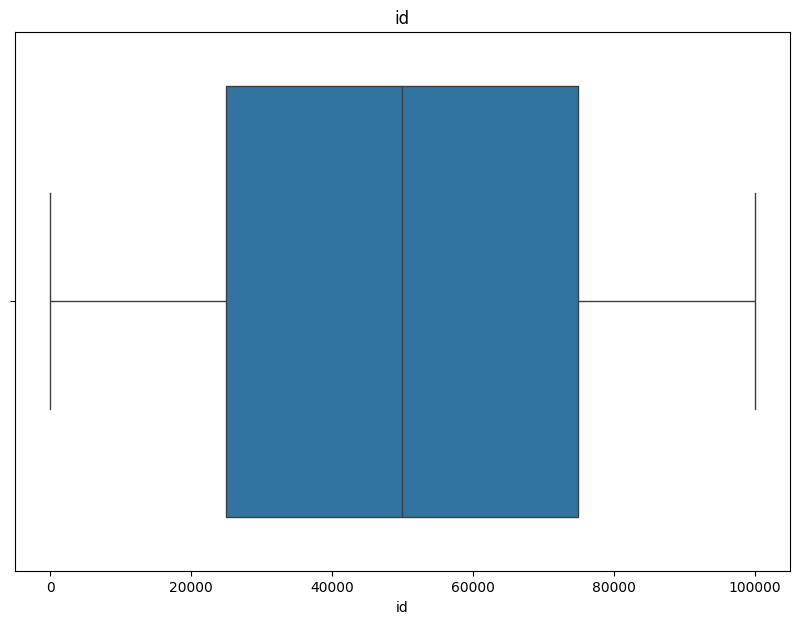

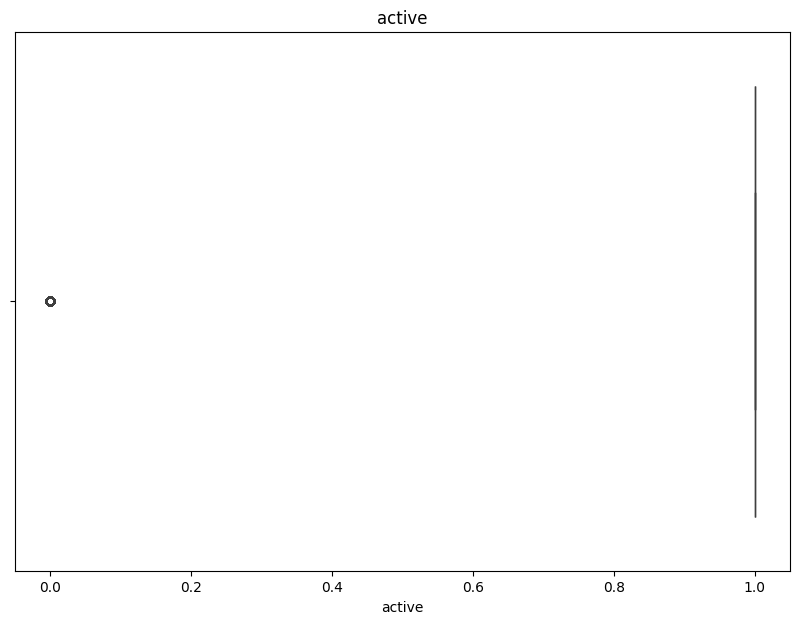

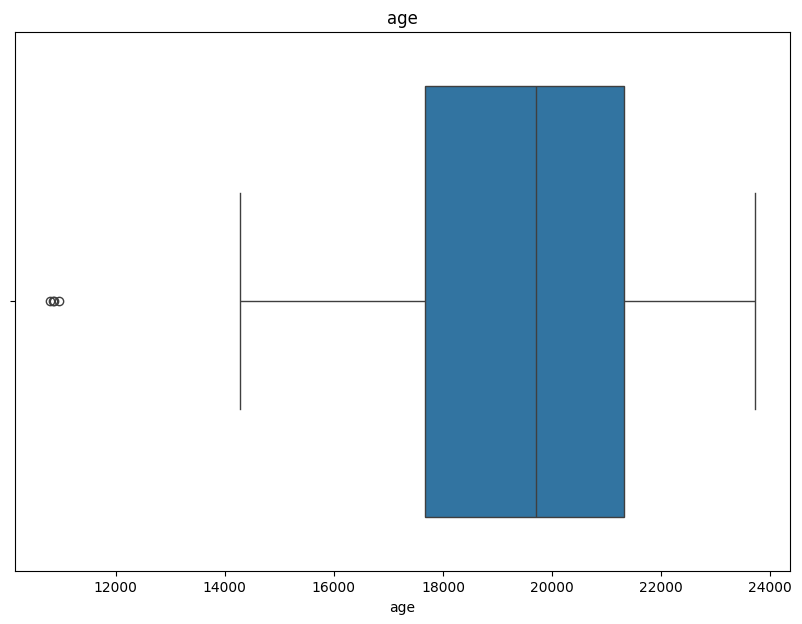

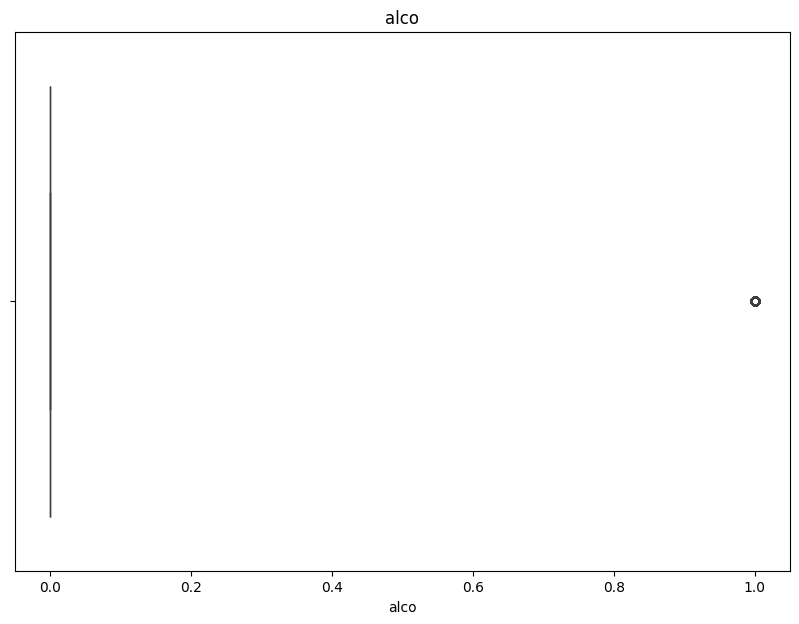

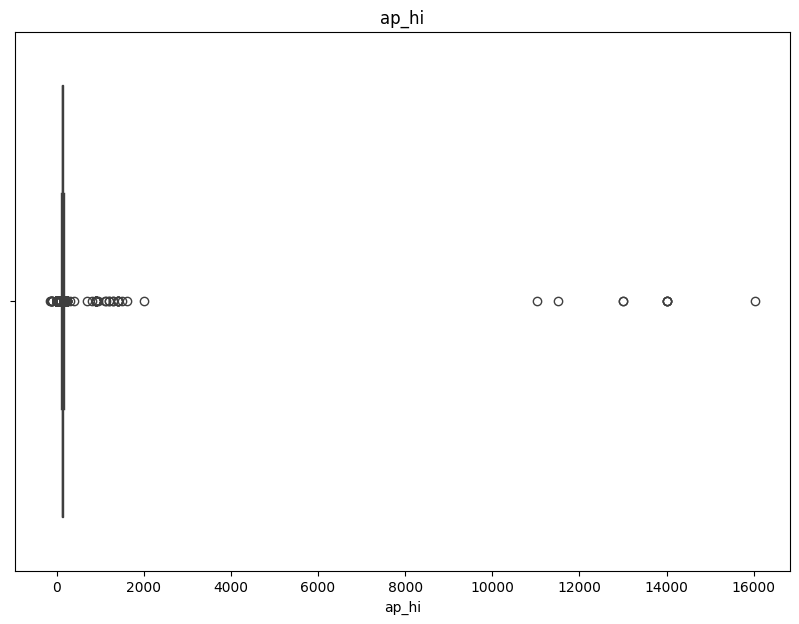

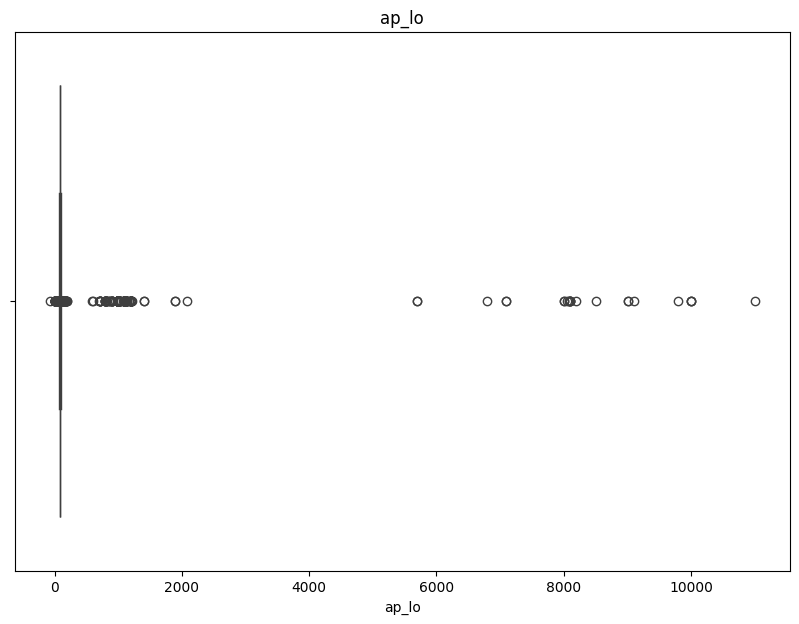

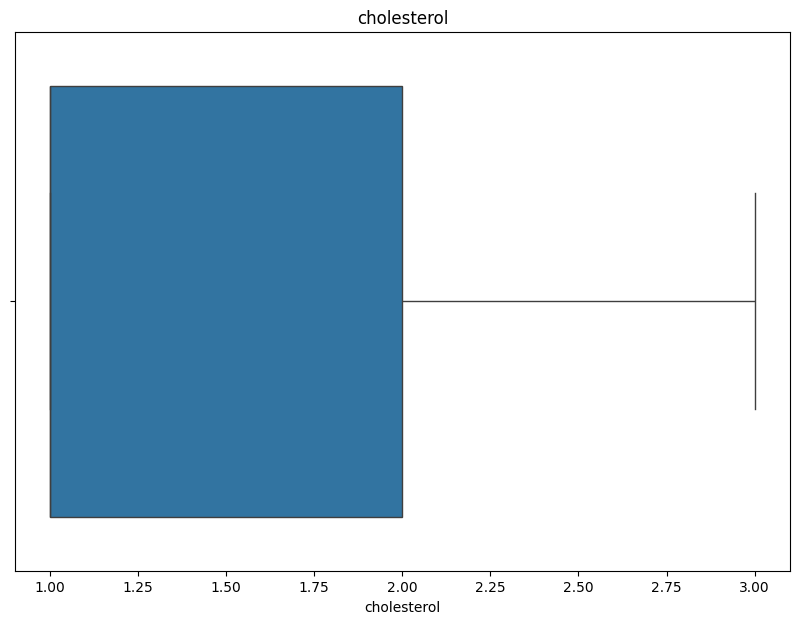

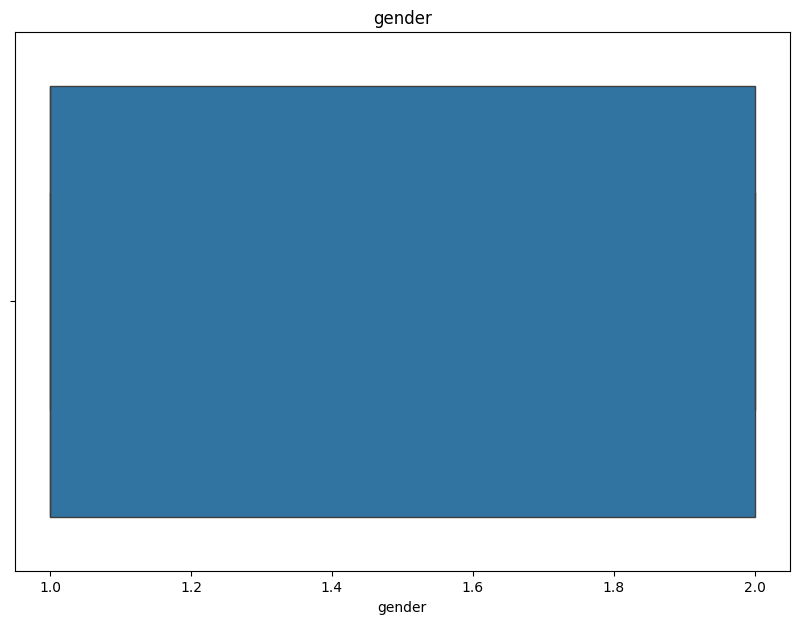

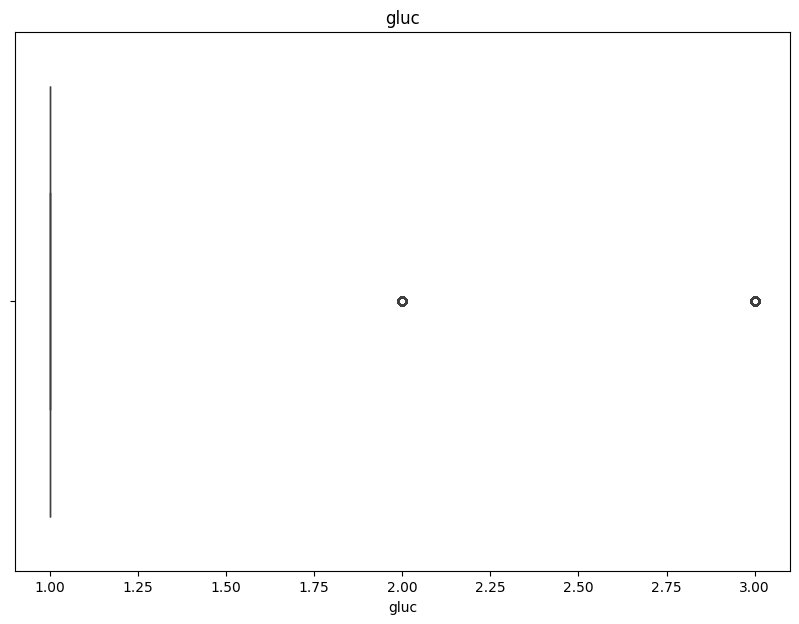

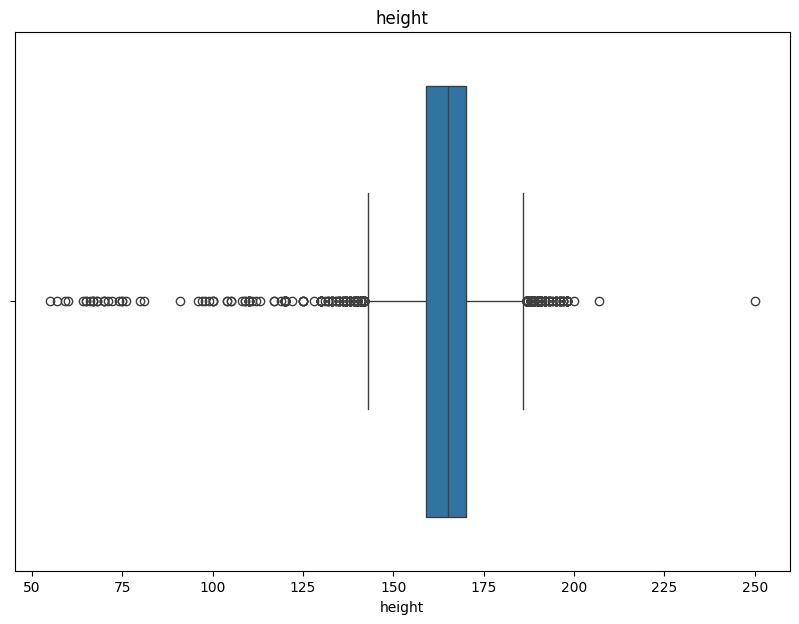

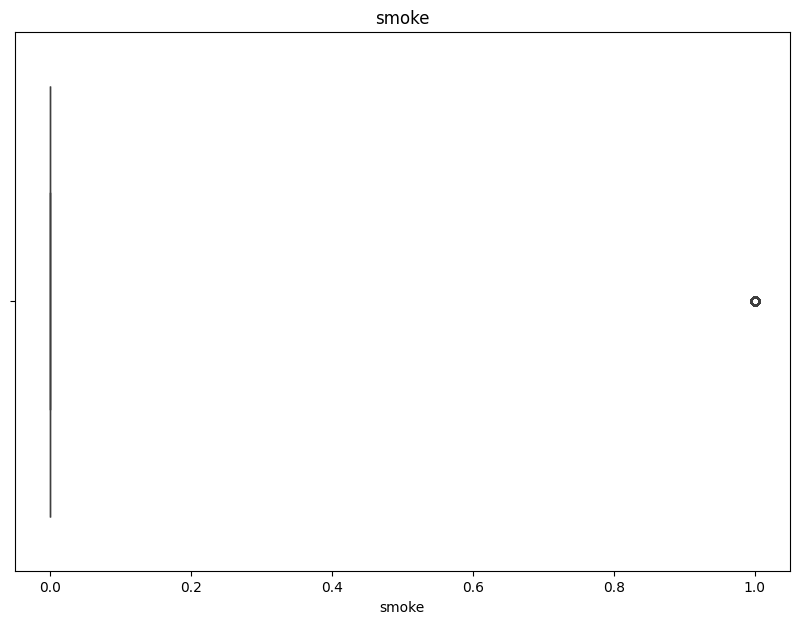

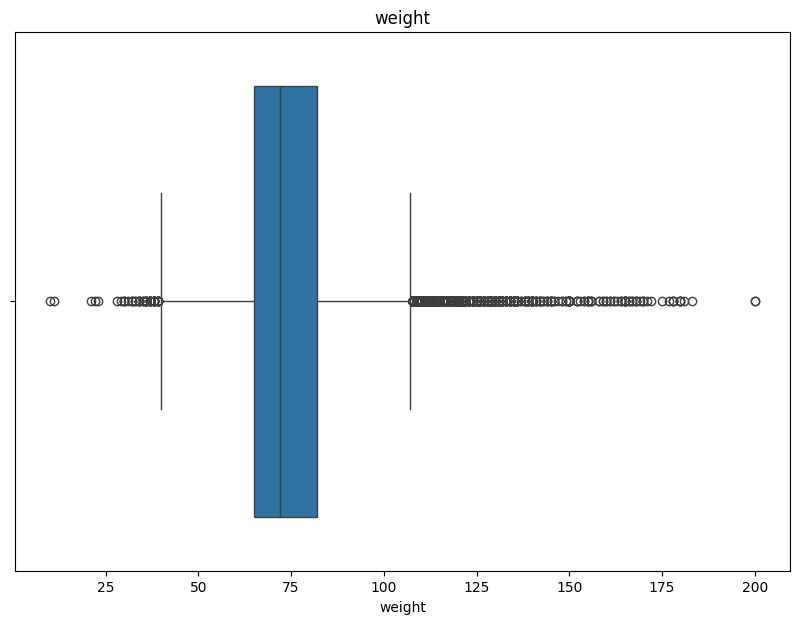

In [10]:
for x in numcols:
  plt.figure(figsize=(10, 7))
  sns.boxplot(data=df, x=x)
  plt.title(x)
  plt.show()


## Histplot

In [11]:
# for col in numcols:
#     plt.figure(figsize=(10, 6))
#     sns.histplot(data=df, x=col, kde=True)
#     plt.title(f'Distribution of {col} with KDE')
#     plt.show()

## CountPlot


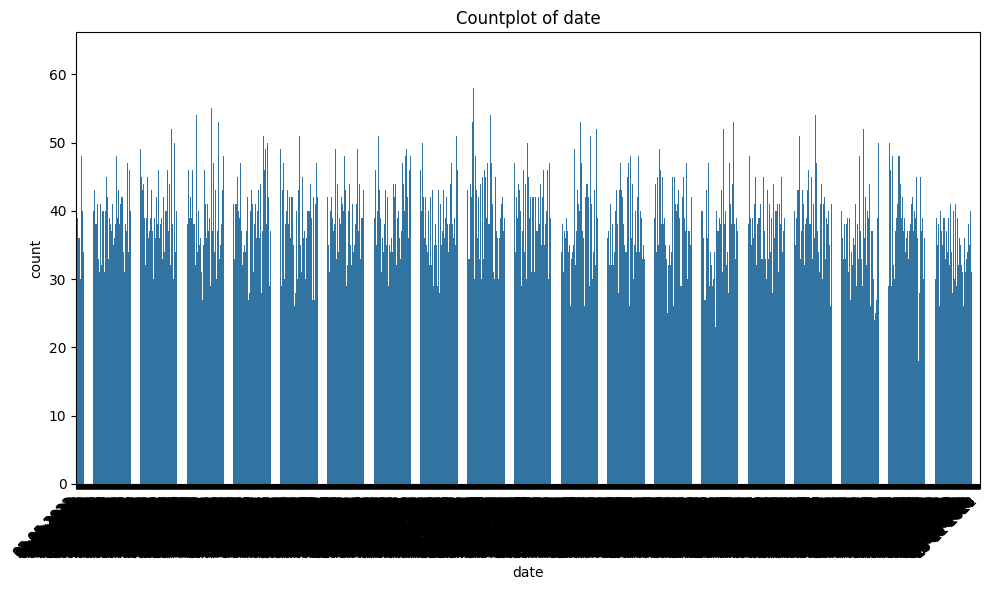

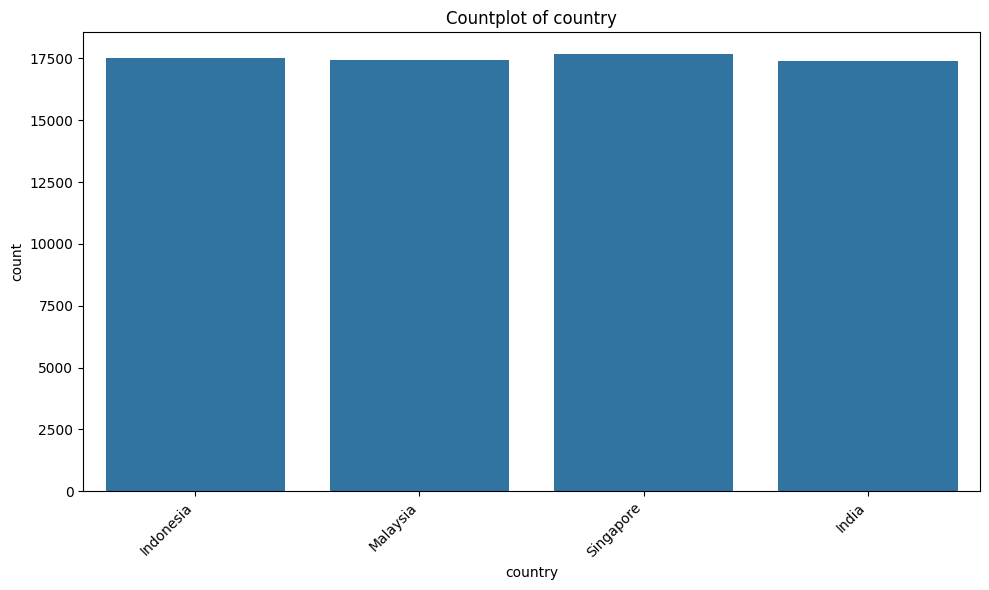

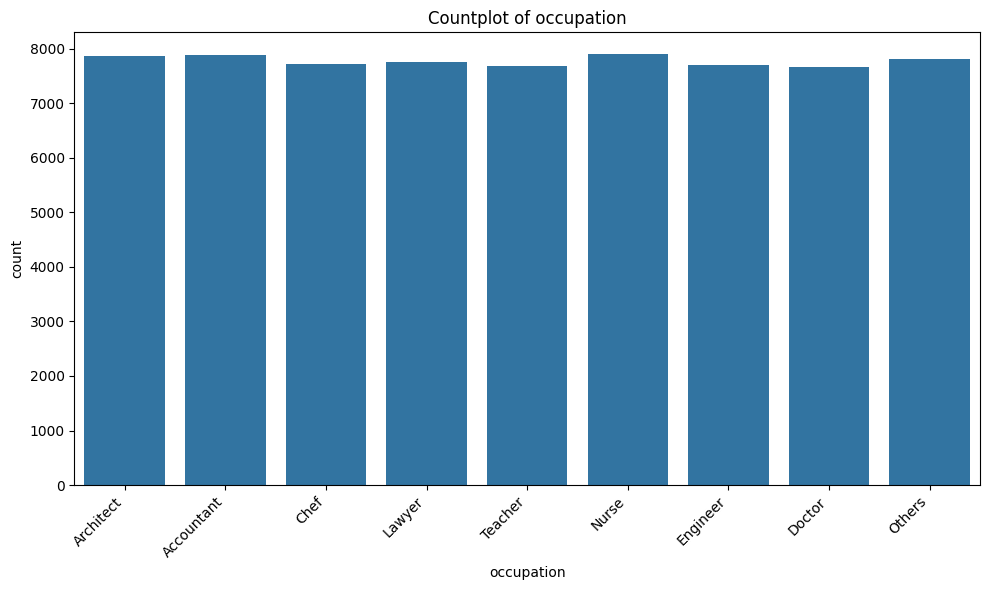

In [12]:
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

## Checking for Missing Data

In [13]:
print(df.isnull().sum())
print(df.info())

date           0
country        0
id             0
active         0
age            0
alco           0
ap_hi          0
ap_lo          0
cholesterol    0
gender         0
gluc           0
height         0
occupation     0
smoke          0
weight         0
disease        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         70000 non-null  object 
 1   country      70000 non-null  object 
 2   id           70000 non-null  int64  
 3   active       70000 non-null  int64  
 4   age          70000 non-null  int64  
 5   alco         70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gender       70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  height       70000 non-null  int64  
 12  occupation   

In [153]:
df = pd.read_csv("./data/project3.csv")


## Feature Engineering


In [154]:
import math as math

def engineer_features(df):
    df["age_year"] = df["age"] / 365.25
    df["age_year"] = df["age_year"].astype(int)

#     df["age_bin"] = pd.cut(
#     df["age_year"],
#     bins=[20, 30, 40, 50, 60, 70],
#     labels=["20-29", "30-39", "40-49", "50-59", "60-69"],
#     include_lowest=True,
#     right=False
# )

    # df["map"] = df["ap_lo"] + (df["ap_hi"] - df["ap_lo"]) / 3 #Mean Arterial Pressure

    # df["bp_ratio"] = df["ap_hi"] / df["ap_lo"].replace(0, np.nan)

    df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

    # df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

    # df['health_index'] = (df['active'] * 1) - (df['smoke'] * 0.5) - (df['alco'] * 0.5)

    # df['cholesterol_gluc_interaction'] = df['cholesterol'] * df['gluc']

    # df["gender_bmi_interaction"] = df["gender"] * df["bmi"]

    # df["obese"] = (df["bmi"] >= 30).astype(int)

    return df

df = engineer_features(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         70000 non-null  object 
 1   country      70000 non-null  object 
 2   id           70000 non-null  int64  
 3   active       70000 non-null  int64  
 4   age          70000 non-null  int64  
 5   alco         70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gender       70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  height       70000 non-null  int64  
 12  occupation   70000 non-null  object 
 13  smoke        70000 non-null  int64  
 14  weight       70000 non-null  float64
 15  disease      70000 non-null  int64  
 16  age_year     70000 non-null  int64  
 17  bmi          70000 non-null  float64
dtypes: float64(2), int64(13), object(3)
memory usa

In [155]:
df['bmi'].value_counts()


,count
bmi,
23.875115,943
23.437500,651
24.221453,489
25.711662,363
22.038567,358
...,...
19.316369,1
53.150759,1
25.637348,1


In [156]:
numcols = df.select_dtypes(np.number).drop(columns=["disease"]).columns.tolist()
cat_cols = df.select_dtypes(object).columns.tolist()

## Correlation Analysis (Numerical Features vs. Disease)

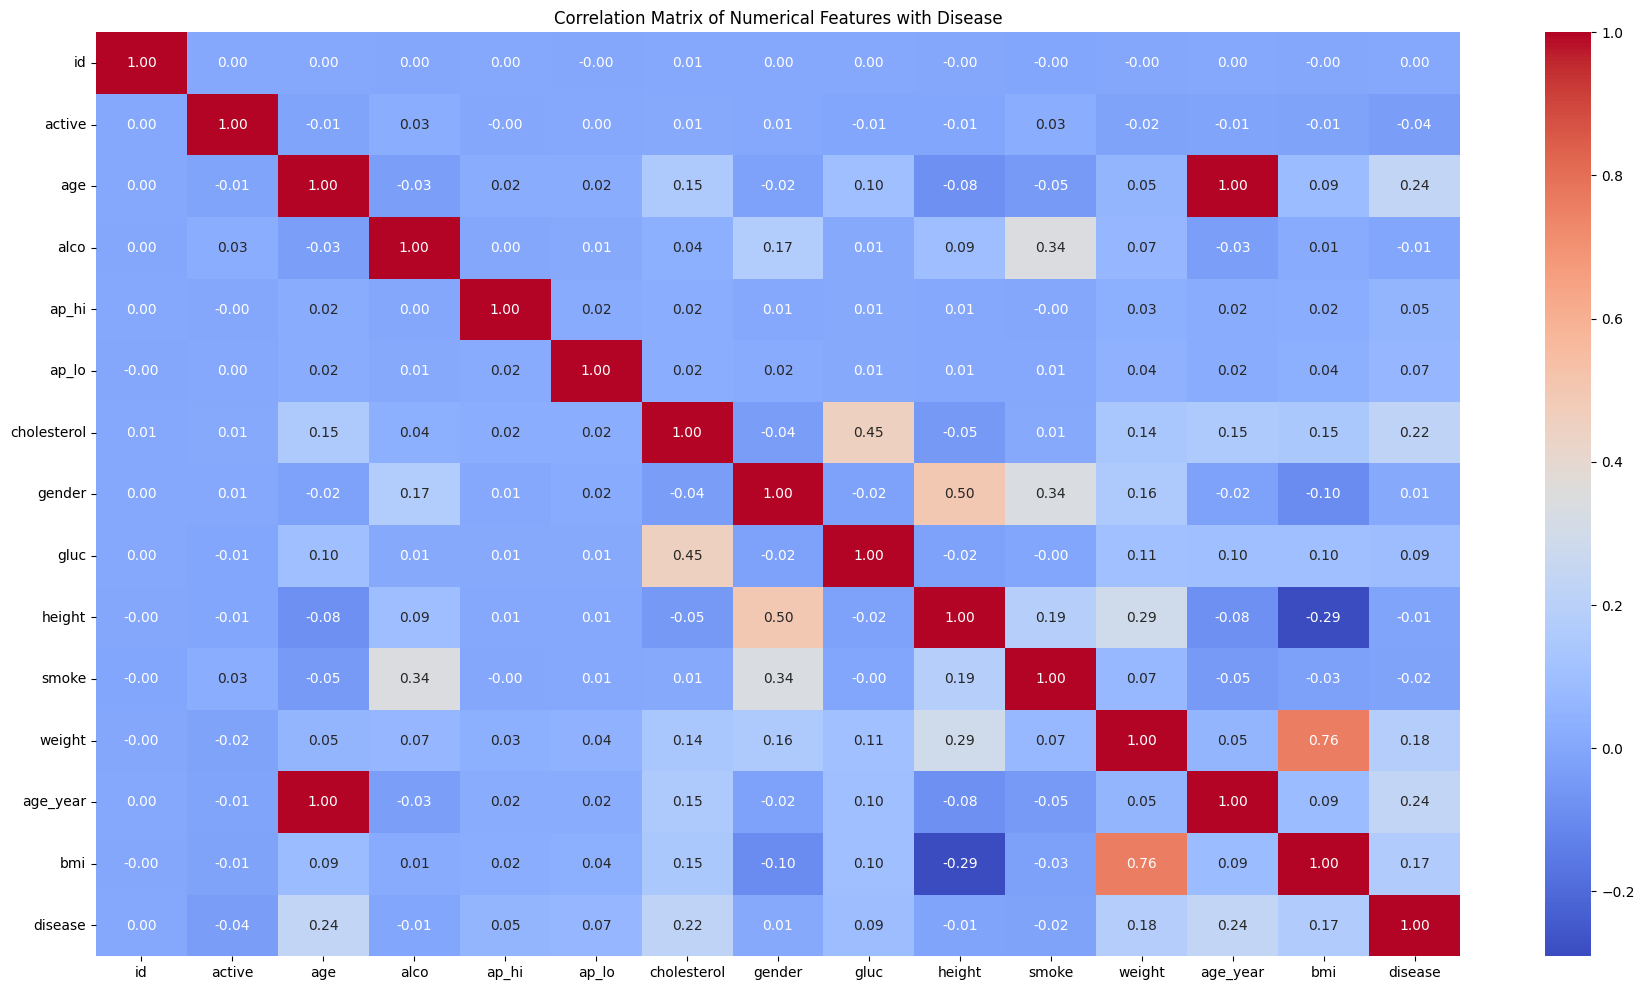

In [157]:
correlation_matrix = df[numcols + ['disease']].corr()

plt.figure(figsize=(22, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features with Disease')
plt.show()

## Relationship between Categorical Features and Disease

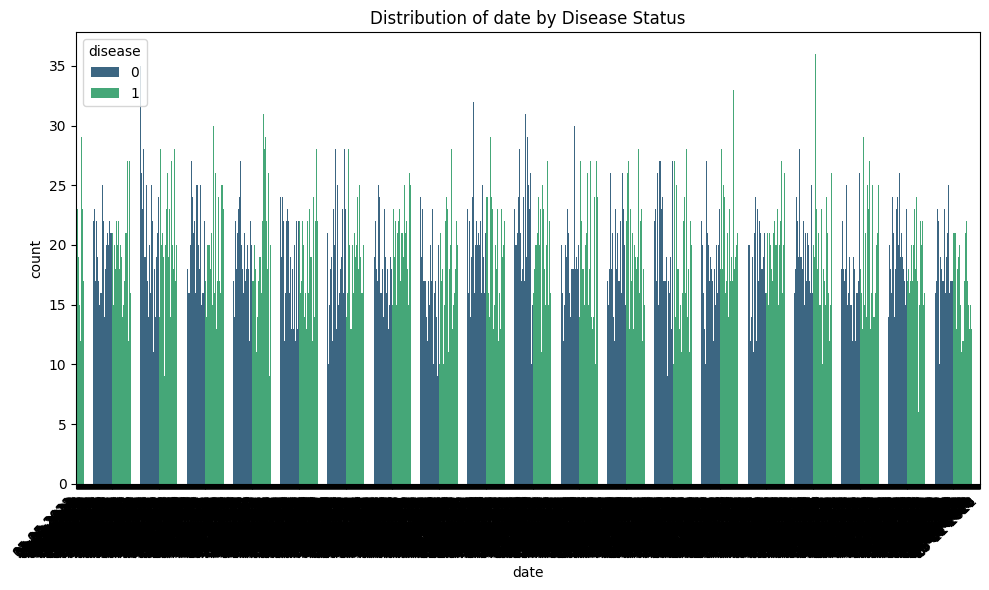

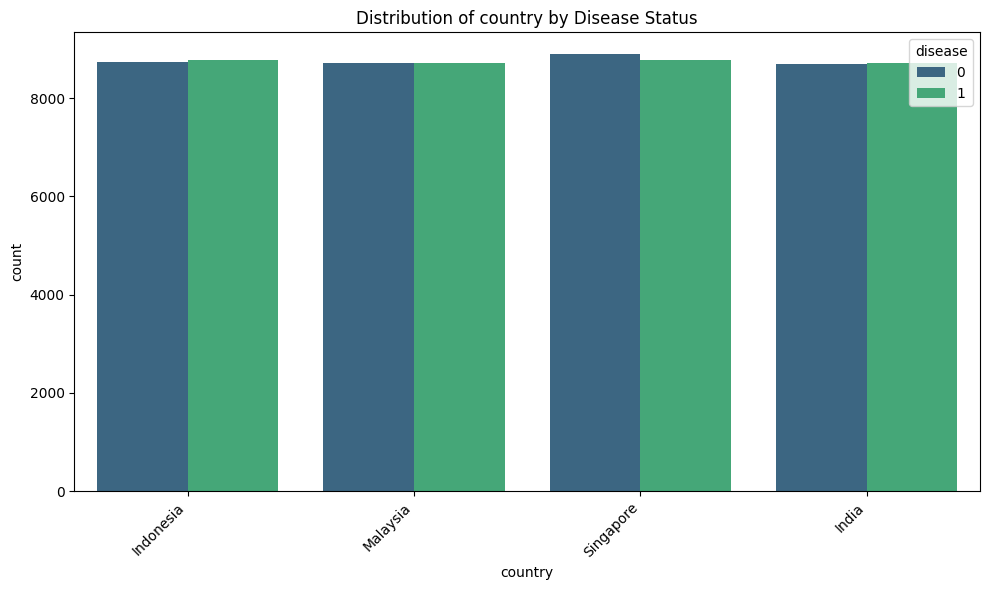

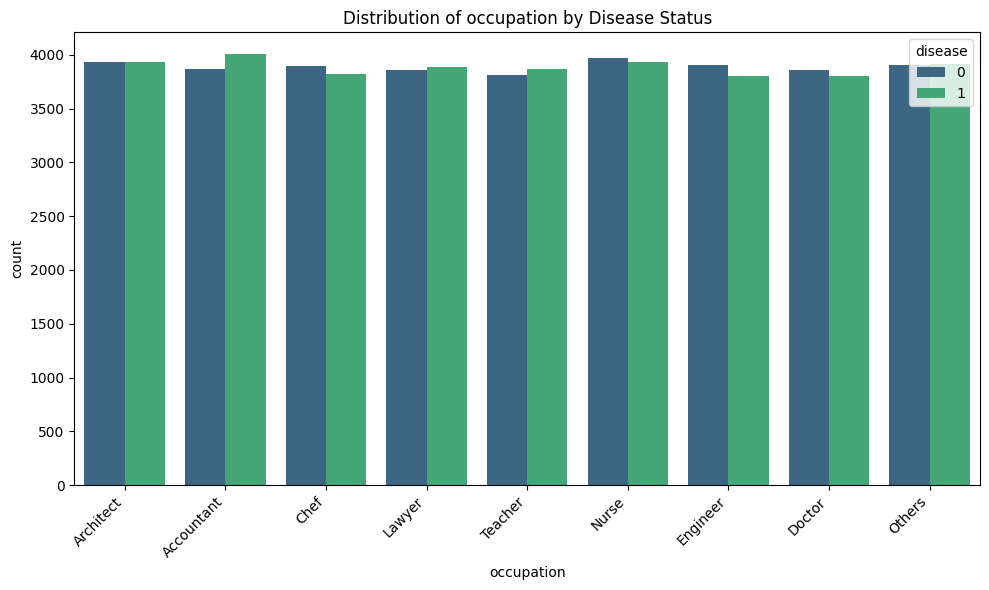

In [158]:
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='disease', palette='viridis')
    plt.title(f'Distribution of {col} by Disease Status')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [159]:
for col in numcols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n}")

id: 0
active: 13739
age: 4
alco: 3764
ap_hi: 1435
ap_lo: 4632
cholesterol: 0
gender: 0
gluc: 10521
height: 519
smoke: 6169
weight: 1819
age_year: 4
bmi: 1995


In [160]:
to_clip = ["age_year", "ap_hi", "ap_lo", "height", "weight", "bmi"]

## Outlier Clipping using IQR

In [161]:
df_clipped = df.copy()

for col in to_clip:
    Q1 = df_clipped[col].quantile(0.25)
    Q3 = df_clipped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clipped[col] = np.clip(df_clipped[col], lower_bound, upper_bound)

print("Outliers in numerical columns have been clipped using the IQR method.")

Outliers in numerical columns have been clipped using the IQR method.


## Boxplots after Outlier Clipping

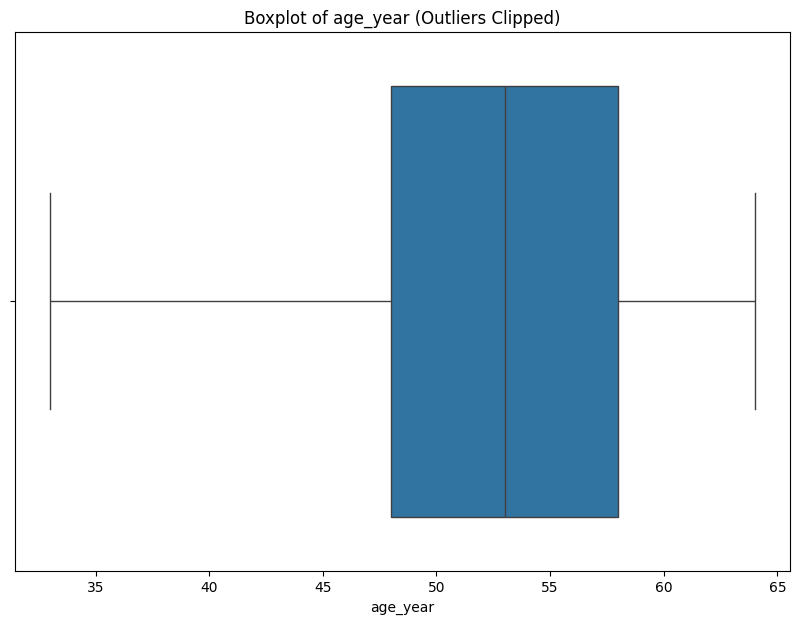

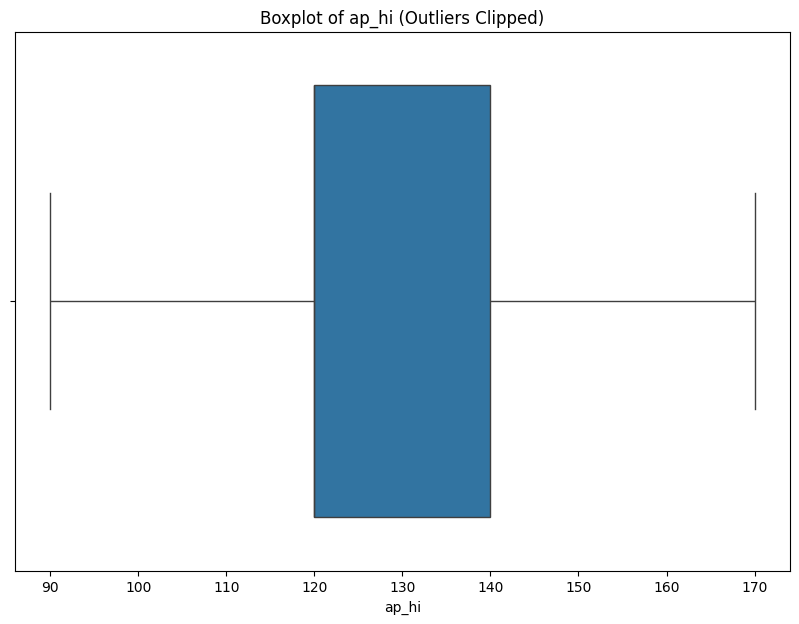

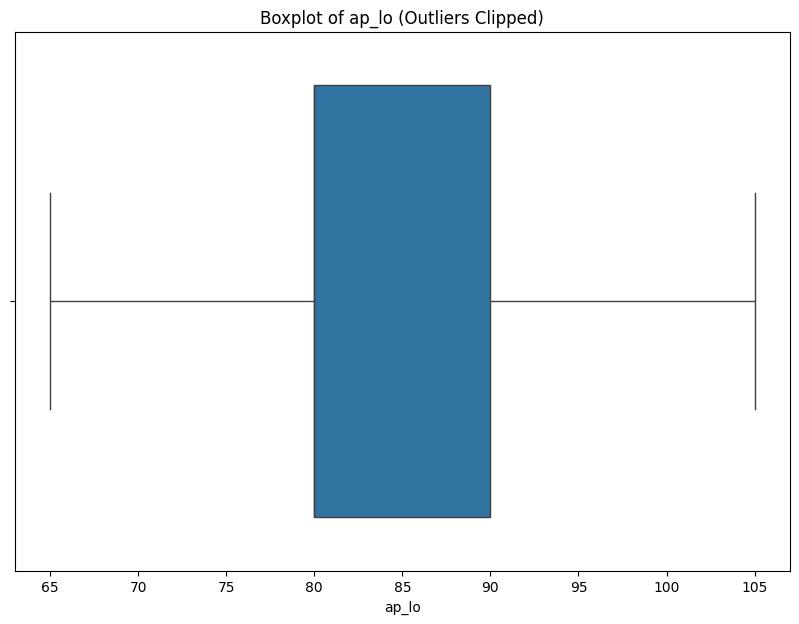

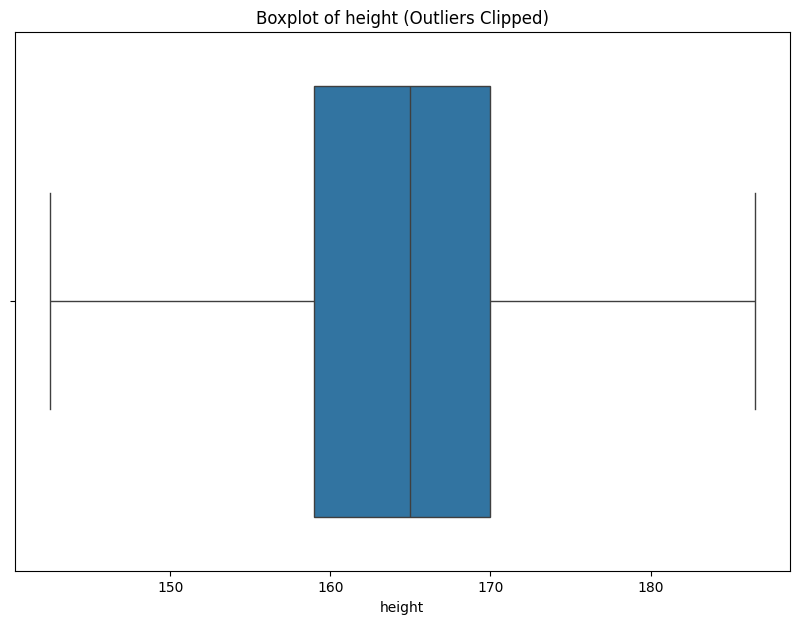

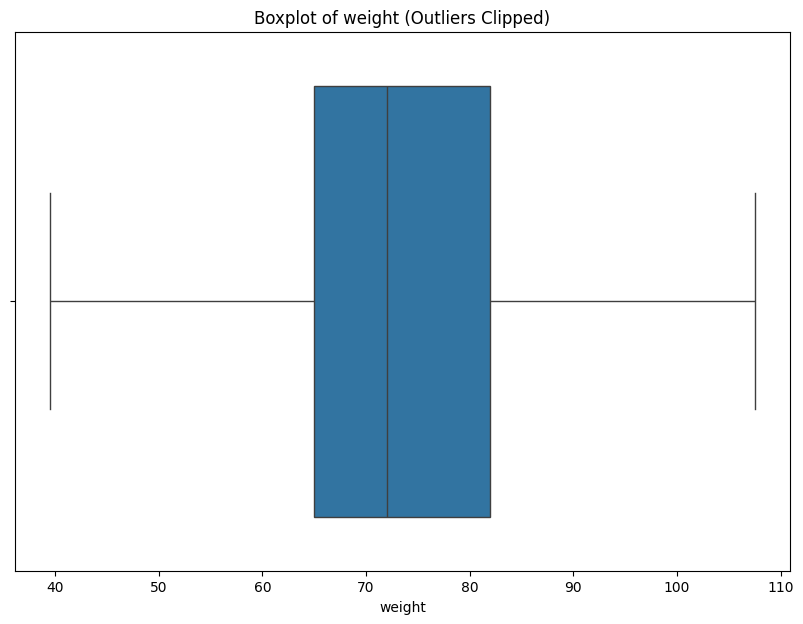

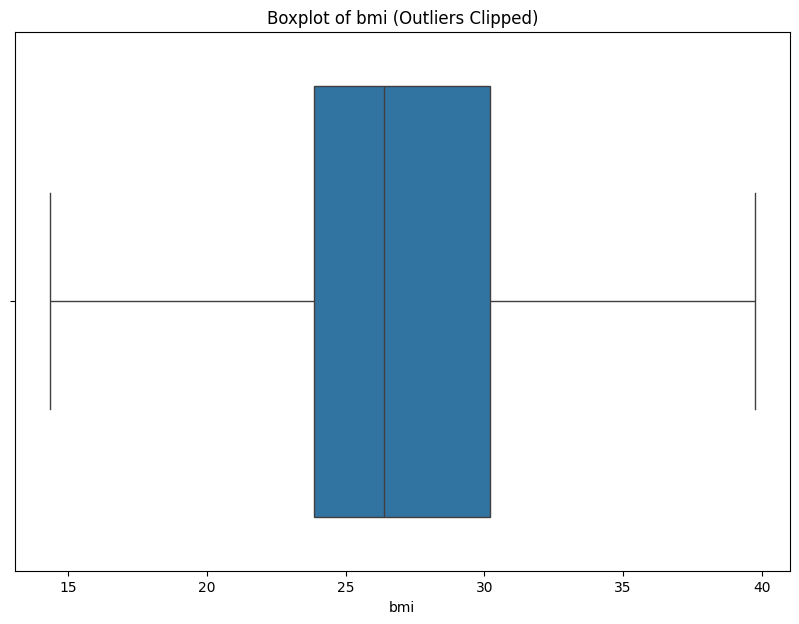

In [162]:
for x in to_clip:
    plt.figure(figsize=(10, 7))
    sns.boxplot(data=df_clipped, x=x)
    plt.title(f'Boxplot of {x} (Outliers Clipped)')
    plt.show()

In [163]:
numcols_clipped = df_clipped.select_dtypes(np.number).drop(columns=["disease"]).columns.tolist()
cat_cols_clipped = df_clipped.select_dtypes(object).columns.tolist()


for col in numcols_clipped:
    Q1 = df_clipped[col].quantile(0.25)
    Q3 = df_clipped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n = ((df_clipped[col] < lower) | (df_clipped[col] > upper)).sum()
    print(f"{col}: {n}")

id: 0
active: 13739
age: 4
alco: 3764
ap_hi: 0
ap_lo: 0
cholesterol: 0
gender: 0
gluc: 10521
height: 0
smoke: 6169
weight: 0
age_year: 0
bmi: 0


In [164]:
print(df["active"].value_counts())
print(df_clipped["active"].value_counts())
print(df["alco"].value_counts())
print(df_clipped["alco"].value_counts())
print(df["smoke"].value_counts())
print(df_clipped["smoke"].value_counts())
print(df["gender"].value_counts())
print(df_clipped["gender"].value_counts())
print(df["gluc"].value_counts())
print(df_clipped["gluc"].value_counts())

active
1    56261
0    13739
Name: count, dtype: int64
active
1    56261
0    13739
Name: count, dtype: int64
alco
0    66236
1     3764
Name: count, dtype: int64
alco
0    66236
1     3764
Name: count, dtype: int64
smoke
0    63831
1     6169
Name: count, dtype: int64
smoke
0    63831
1     6169
Name: count, dtype: int64
gender
1    45530
2    24470
Name: count, dtype: int64
gender
1    45530
2    24470
Name: count, dtype: int64
gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64
gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64


In [165]:
df_clipped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         70000 non-null  object 
 1   country      70000 non-null  object 
 2   id           70000 non-null  int64  
 3   active       70000 non-null  int64  
 4   age          70000 non-null  int64  
 5   alco         70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gender       70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  height       70000 non-null  float64
 12  occupation   70000 non-null  object 
 13  smoke        70000 non-null  int64  
 14  weight       70000 non-null  float64
 15  disease      70000 non-null  int64  
 16  age_year     70000 non-null  int64  
 17  bmi          70000 non-null  float64
dtypes: float64(3), int64(12), object(3)
memory usa

In [166]:
df.shape

(70000, 18)

In [167]:
df.columns

Index(['date', 'country', 'id', 'active', 'age', 'alco', 'ap_hi', 'ap_lo',
       'cholesterol', 'gender', 'gluc', 'height', 'occupation', 'smoke',
       'weight', 'disease', 'age_year', 'bmi'],
      dtype='object')

## Splitting into X and Y

In [178]:
x = df_clipped.drop(columns=["date", "id", "disease", "age", "country", "gender", "occupation" ,"weight", "smoke","alco", "height"])
y = df_clipped["disease"]
print(x.shape)
print(y.shape)

(70000, 7)
(70000,)


In [179]:
y.value_counts()

,count
disease,
0,35021
1,34979


## Selecting x num_cols and cat_cols

In [180]:

x_temp = x.copy()
# x_temp['hypertension_stage'] = x_temp['hypertension_stage'].astype('object') if  x_temp["hypertension_stage"] else []

x_num_cols = x_temp.select_dtypes(include = np.number).columns.tolist()
x_cat_cols = x_temp.select_dtypes(exclude = np.number).columns.tolist()
print(x_num_cols)
print(x_cat_cols)

['active', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'age_year', 'bmi']
[]


## Splitting into Train and Test Set

In [181]:
from sklearn.model_selection import train_test_split


# x['hypertension_stage'] = x['hypertension_stage'].astype('object')

x_train, x_test, y_train, y_test = train_test_split(x , y, test_size=0.2, random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(56000, 7)
(56000,)
(14000, 7)
(14000,)


## Transforming the Data

In [182]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


# Create a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), x_num_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), x_cat_cols)
    ],
    remainder='passthrough' # Keep other columns as they are
)

# Fit the preprocessor on x_train and transform x_train and x_test
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

# Get feature names after one-hot encoding
# Adjusted to get feature names from the OneHotEncoder within the pipeline
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(x_cat_cols) if x_cat_cols else []
all_feature_names = (
    x_num_cols + list(cat_feature_names)
    if len(cat_feature_names) > 0
    else x_num_cols
)

# Convert the processed arrays back to DataFrames
x_train_processed_df = pd.DataFrame(x_train_processed, columns=all_feature_names, index=x_train.index) #type: ignore
x_test_processed_df = pd.DataFrame(x_test_processed, columns=all_feature_names, index=x_test.index) #type: ignore

print("Shape of x_train_processed_df:", x_train_processed_df.shape)
print("Shape of x_test_processed_df:", x_test_processed_df.shape)
print("First 5 rows of x_train_processed_df:")
x_train_processed_df.head()

Shape of x_train_processed_df: (56000, 7)
Shape of x_test_processed_df: (14000, 7)
First 5 rows of x_train_processed_df:


,active,ap_hi,ap_lo,cholesterol,gluc,age_year,bmi
47339,0.494106,0.201891,0.908707,0.932864,-0.394633,0.917077,1.308144
67456,-2.023859,0.812070,0.908707,-0.539194,-0.394633,-1.151520,-0.144144
12308,0.494106,1.422248,2.012865,-0.539194,-0.394633,0.621563,0.619949
32557,0.494106,-0.408288,0.025380,-0.539194,-0.394633,1.508105,-0.407321
664,0.494106,-0.408288,-0.195452,-0.539194,-0.394633,0.326050,-0.809683


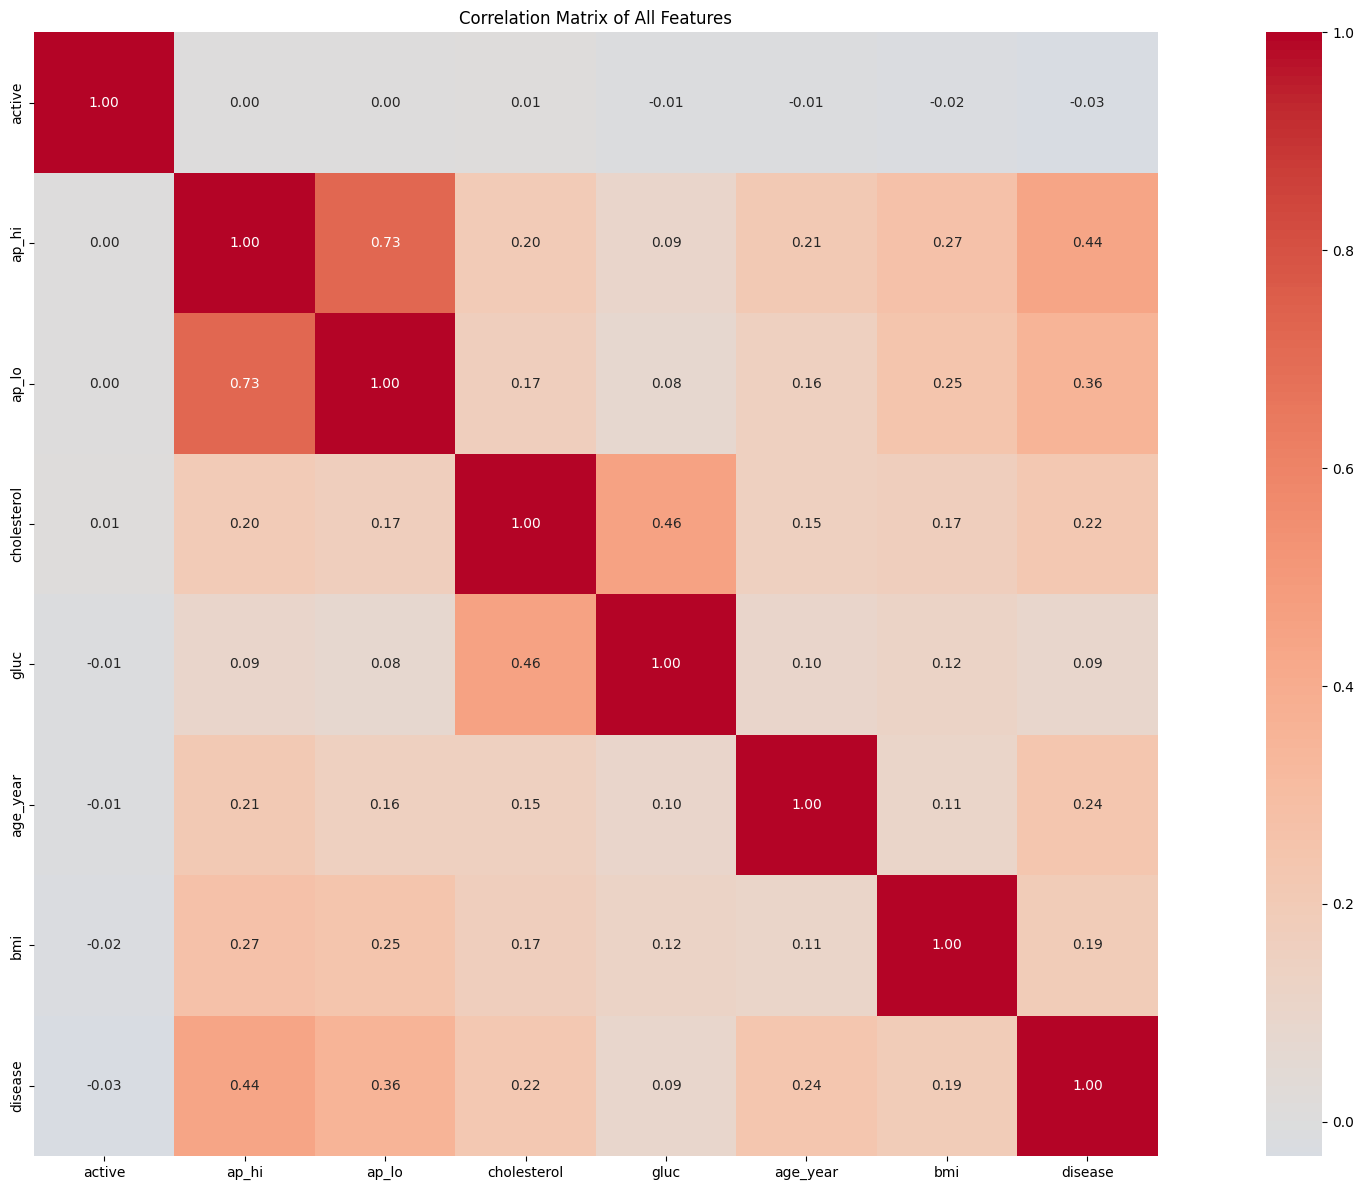

In [183]:
from sklearn.preprocessing import LabelEncoder


# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y_train)

# Combine features and target
corr_df = x_train_processed_df.copy()
corr_df["disease"] = y_encoded

# Compute correlation matrix
correlation_matrix = corr_df.corr(numeric_only=True)

# Plot full correlation matrix
plt.figure(figsize=(22, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of All Features")
plt.tight_layout()
plt.show()

## Model Fitting


In [184]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss


# Initialize classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
    # "SVM": SVC(random_state=42, probability=True), # probability=True for log_loss
    "K-Nearest Neighbors": KNeighborsClassifier()
}

best_model = None
best_f1_score = -1
model_results = {}

for name, model in classifiers.items():
    print(f"\nTraining {name}...")
    model.fit(x_train_processed_df, y_train)
    y_pred = model.predict(x_test_processed_df)
    y_pred_proba = model.predict_proba(x_test_processed_df)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    lloss = log_loss(y_test, y_pred_proba)

    model_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "LogLoss": lloss
    }

    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, LogLoss: {lloss:.4f}")

    if f1 > best_f1_score:
        best_f1_score = f1
        best_model = model

print("\n--- Model Evaluation Results ---")
for name, metrics in model_results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

print(f"\nBest Model based on F1-Score: {best_model.__class__.__name__}")
print(f"Best F1-Score: {best_f1_score:.4f}")



Training Logistic Regression...
Logistic Regression - Accuracy: 0.7314, Precision: 0.7594, Recall: 0.6787, F1-Score: 0.7168, LogLoss: 0.5587

Training Decision Tree...
Decision Tree - Accuracy: 0.6451, Precision: 0.6510, Recall: 0.6279, F1-Score: 0.6393, LogLoss: 11.8980

Training Random Forest...
Random Forest - Accuracy: 0.6808, Precision: 0.6792, Recall: 0.6874, F1-Score: 0.6833, LogLoss: 0.9703

Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.7381, Precision: 0.7532, Recall: 0.7098, F1-Score: 0.7308, LogLoss: 0.5392

Training XGBoost...
XGBoost - Accuracy: 0.7345, Precision: 0.7540, Recall: 0.6974, F1-Score: 0.7246, LogLoss: 0.5495

Training CatBoost...
CatBoost - Accuracy: 0.7420, Precision: 0.7636, Recall: 0.7022, F1-Score: 0.7316, LogLoss: 0.5417

Training K-Nearest Neighbors...
K-Nearest Neighbors - Accuracy: 0.6977, Precision: 0.7010, Recall: 0.6914, F1-Score: 0.6962, LogLoss: 2.4380

--- Model Evaluation Results ---

Logistic Regression:
  Accuracy: 0.7314
  Pr

Best Model based on F1-Score: GradientBoostingClassifier   Best F1-Score: 0.7308
without  ("country", "gender")  
Best Model based on F1-Score: CatBoostClassifier
Best F1-Score: 0.7312 without ("country", "gender", "occupation)  
Best Model based on F1-Score: CatBoostClassifier
Best F1-Score: 0.7316 [added feature "bmi", "age_year"] (dropped "age", "country", "gender", "occupation" ,"weight", "smoke","alco", "height")

In [185]:
feature_importance = pd.DataFrame({
    "Feature": x_train_processed_df.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

       Feature  Importance
1        ap_hi   28.402963
5     age_year   21.979590
6          bmi   20.898126
2        ap_lo   10.263589
3  cholesterol   10.141178
4         gluc    4.713828
0       active    3.600726


In [186]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    x_test_processed_df,
    y_test,
    scoring="f1_weighted",
    n_repeats=20,
    random_state=42
)

importance = (
    pd.Series(result.importances_mean, index=x_test_processed_df.columns)
    .sort_values(ascending=False)
)

print(importance)

ap_hi          0.141337
cholesterol    0.038520
age_year       0.027556
ap_lo          0.010661
bmi            0.007398
active         0.003960
gluc           0.002677
dtype: float64


In [188]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)

# Define parameter distributions
param_dist = {
    "iterations": randint(100, 401),       # 100 - 400
    "learning_rate": uniform(0.01, 0.19),  # 0.01 - 0.20
    "depth": randint(4, 9),                # 4 - 8
    "l2_leaf_reg": randint(1, 10),         # 1 - 9
}

estimator = best_model if best_model.__class__.__name__ == "CatBoostClassifier" else CatBoostClassifier(random_state=42, verbose=0, early_stopping_rounds=50)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_dist,
    n_iter=20,            # Number of random combinations to try
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

print("Starting Random Hyperparameter Search for CatBoostClassifier...")

# Fit RandomizedSearchCV
random_search.fit(x_train_processed_df, y_train)

print("\n--- Random Search Results ---")
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Cross-Validated F1-Score: {random_search.best_score_:.4f}")

# Best model
best_tuned_model = random_search.best_estimator_

# Evaluate on test set
y_pred_tuned = best_tuned_model.predict(x_test_processed_df)
y_pred_proba_tuned = best_tuned_model.predict_proba(x_test_processed_df)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
lloss_tuned = log_loss(y_test, y_pred_proba_tuned)

print("\n--- Best Tuned CatBoost Model Performance on Test Set ---")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")
print(f"LogLoss: {lloss_tuned:.4f}")

Starting Random Hyperparameter Search for CatBoostClassifier...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- Random Search Results ---
Best Parameters: {'depth': 8, 'iterations': 152, 'l2_leaf_reg': 8, 'learning_rate': np.float64(0.07778313207178196)}
Best Cross-Validated F1-Score: 0.7244

--- Best Tuned CatBoost Model Performance on Test Set ---
Accuracy: 0.7415
Precision: 0.7611
Recall: 0.7052
F1-Score: 0.7321
LogLoss: 0.5385


Best Tuned CatBoost Model Performance Accuracy: 0.7415
Precision: 0.7611
Recall: 0.7052
F1-Score: 0.7321
LogLoss: 0.5385
f1 score increased by 0.0005  
Best Model based on F1-Score: CatBoostClassifier (before fine tuning)
Best F1-Score: 0.7316 [added feature "bmi", "age_year"] (dropped "age", "country", "gender", "occupation" ,"weight", "smoke","alco", "height")

In [189]:
import pickle as pkl
with open("best_tuned_model.pkl", "wb") as f:
    pkl.dump(best_tuned_model, f)
